In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/swaptr/fifa-wc-2026-matches/matches.csv")

df.head()

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,...,11,3,10,8,35,10,7,0.0,1.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   round               92 non-null     object 
 1   gameweek            72 non-null     float64
 2   dayofweek           92 non-null     object 
 3   date                92 non-null     object 
 4   start_time          92 non-null     object 
 5   home_team           92 non-null     object 
 6   away_team           92 non-null     object 
 7   score               92 non-null     object 
 8   home_score          89 non-null     float64
 9   away_score          89 non-null     float64
 10  attendance          92 non-null     object 
 11  venue               92 non-null     object 
 12  referee             92 non-null     object 
 13  home_formation      92 non-null     object 
 14  away_formation      92 non-null     object 
 15  home_manager        92 non-null     object 
 16  away_manag

In [4]:
df.describe()

,gameweek,home_score,away_score,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
count,72.000000,89.000000,89.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,88.000000,88.000000
mean,2.000000,1.775281,1.179775,52.336957,47.793478,4.760870,3.586957,13.989130,10.750000,2.391304,...,11.413043,11.217391,5.206522,3.967391,17.913043,14.250000,7.978261,8.619565,1.818182,1.715909
std,0.822226,1.550314,1.163476,13.534877,13.518842,3.075495,2.395748,6.473097,5.923737,1.904053,...,3.981143,4.174296,3.525536,2.723327,10.779154,7.615232,3.999940,3.133802,1.497473,1.567991
min,1.000000,0.000000,0.000000,24.000000,21.000000,0.000000,0.000000,2.000000,2.000000,0.000000,...,3.000000,1.000000,0.000000,0.000000,4.000000,1.000000,1.000000,3.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,42.000000,38.000000,2.750000,2.000000,8.750000,7.000000,1.000000,...,9.000000,8.000000,3.000000,2.000000,10.750000,9.000000,5.000000,6.000000,1.000000,0.000000
50%,2.000000,1.000000,1.000000,52.500000,47.500000,4.000000,3.000000,13.000000,9.000000,2.000000,...,11.000000,11.000000,4.000000,3.000000,15.000000,13.000000,7.000000,8.500000,2.000000,1.000000
75%,3.000000,3.000000,2.000000,62.000000,58.000000,6.250000,5.000000,17.500000,13.000000,3.000000,...,13.000000,14.000000,7.000000,5.000000,22.250000,17.250000,10.000000,11.000000,3.000000,3.000000
max,3.000000,7.000000,5.000000,79.000000,76.000000,15.000000,10.000000,32.000000,35.000000,9.000000,...,24.000000,24.000000,19.000000,14.000000,56.000000,47.000000,21.000000,16.000000,8.000000,6.000000


In [5]:
df.shape

(92, 42)

In [6]:
df.columns

Index(['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team',
       'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue',
       'referee', 'home_formation', 'away_formation', 'home_manager',
       'away_manager', 'home_captain', 'away_captain', 'home_possession',
       'away_possession', 'home_sot', 'away_sot', 'home_total_shots',
       'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow',
       'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls',
       'away_fouls', 'home_corners', 'away_corners', 'home_crosses',
       'away_crosses', 'home_interceptions', 'away_interceptions',
       'home_offsides', 'away_offsides', 'notes'],
      dtype='object')

# Missing values 

In [7]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

notes            87
gameweek         20
away_offsides     4
home_offsides     4
home_score        3
away_score        3
dtype: int64

In [8]:
df.drop(columns="notes", inplace=True)

# Scores and penalties 

In [9]:
df[df["home_score"].isna()][["score", "home_score", "away_score"]]

,score,home_score,away_score
74,(3)1–1(4),NaN,NaN
75,(2)1–1(3),NaN,NaN
85,(2)1–1(4),NaN,NaN


# Update ( home_score , away_score )  with the actual score values 

In [10]:
import re

def extract_regular_score(score):
    nums = re.findall(r'\d+', str(score))

    if len(nums) == 4:
        return nums[1], nums[2]
    elif len(nums) == 2:
        return nums[0], nums[1]
    else:
        return None, None

print(extract_regular_score("(3)1–1(4)"))

('1', '1')


In [11]:
df.loc[[74,75,85], "score"].apply(extract_regular_score)

74    (1, 1)
75    (1, 1)
85    (1, 1)
Name: score, dtype: object

In [12]:
scores = df["score"].apply(extract_regular_score)

df["home_score"] = scores.str[0]
df["away_score"] = scores.str[1]

In [13]:
df["home_score"] = pd.to_numeric(df["home_score"])
df["away_score"] = pd.to_numeric(df["away_score"])

In [14]:
df.loc[[74,75,85], "score"].apply(extract_regular_score)

74    (1, 1)
75    (1, 1)
85    (1, 1)
Name: score, dtype: object

In [15]:
df.loc[[74,75,85]]

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
74,Round of 32,NaN,Mon,2026-06-29,16:30,Germany,Paraguay,(3)1–1(4),1,1,...,18,12,16,6,56,21,4,13,4.0,1.0
75,Round of 32,NaN,Mon,2026-06-29,19:00,Netherlands,Morocco,(2)1–1(3),1,1,...,18,15,5,8,10,18,11,10,3.0,0.0
85,Round of 32,NaN,Fri,2026-07-03,13:00,Australia,Egypt,(2)1–1(4),1,1,...,12,14,4,7,24,24,9,8,0.0,3.0


In [16]:
df.duplicated().sum()

np.int64(0)

# Matches Analysis

In [17]:
print("Number of Matches:", len(df))

Number of Matches: 92


# Sum of goals 

In [18]:
total_goals = df["home_score"].sum() + df["away_score"].sum()

print(total_goals)

269


# average of goals

In [19]:
avg_goals = total_goals / len(df)

print(avg_goals)

2.9239130434782608


# goals distribution 

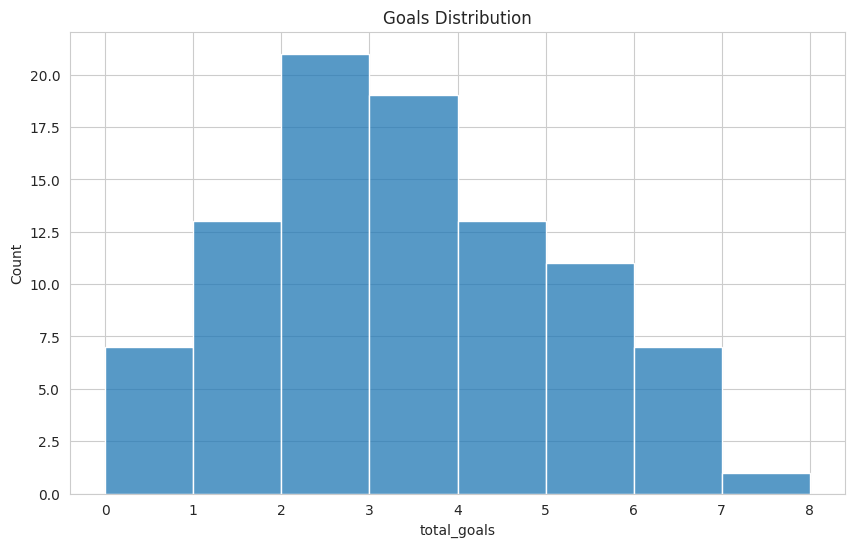

In [20]:
df["total_goals"] = df["home_score"] + df["away_score"]

sns.histplot(df["total_goals"], bins=8)

plt.title("Goals Distribution")
plt.show()

# Attendence analysis 

In [21]:
df["attendance"].describe()

count         92
unique        48
top       52,497
freq           6
Name: attendance, dtype: object

In [22]:
top_attendance = df.sort_values(
    "attendance",
    ascending=False
)[["home_team","away_team","attendance"]]

top_attendance.head(10)

,home_team,away_team,attendance
0,Mexico,South Africa,"80,824"
23,Uzbekistan,Colombia,"80,824"
78,Mexico,Ecuador,"80,824"
53,Czechia,Mexico,"80,824"
91,Mexico,England,"80,824"
5,Brazil,Morocco,"80,663"
90,Brazil,Norway,"80,663"
67,Panama,England,"80,663"
77,France,Sweden,"80,663"
55,Ecuador,Germany,"80,663"


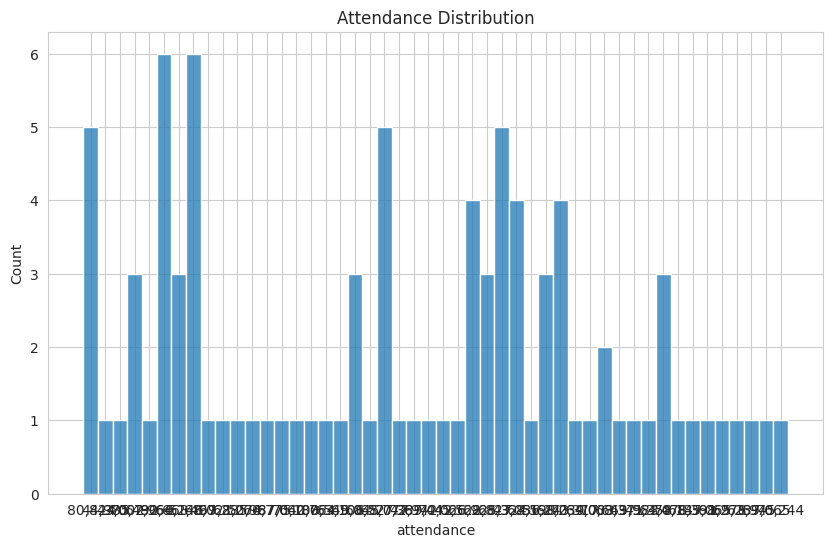

In [23]:
sns.histplot(df["attendance"])

plt.title("Attendance Distribution")
plt.show()

# Possession Analysis

In [24]:
df["home_possession"].describe()

count    92.000000
mean     52.336957
std      13.534877
min      24.000000
25%      42.000000
50%      52.500000
75%      62.000000
max      79.000000
Name: home_possession, dtype: float64

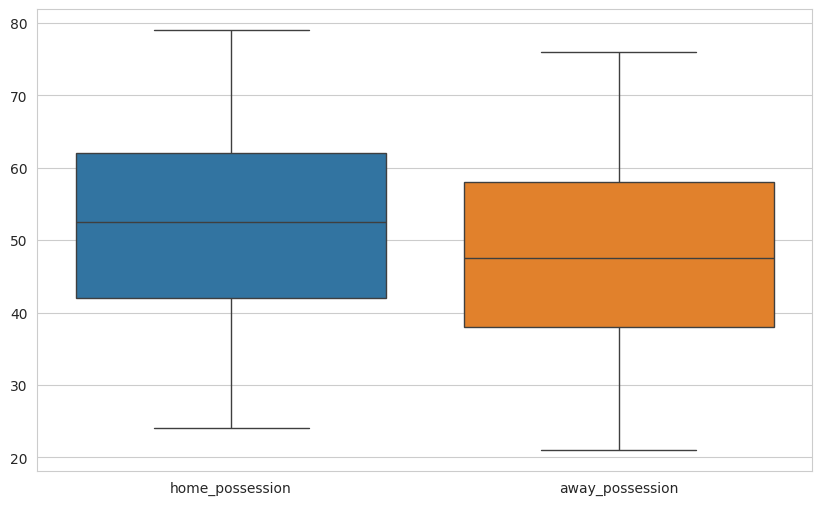

In [25]:
sns.boxplot(data=df[["home_possession","away_possession"]])

plt.show()

# Shots

In [26]:
df["home_total_shots"].describe()

count    92.000000
mean     13.989130
std       6.473097
min       2.000000
25%       8.750000
50%      13.000000
75%      17.500000
max      32.000000
Name: home_total_shots, dtype: float64

In [27]:
df["away_total_shots"].describe()

count    92.000000
mean     10.750000
std       5.923737
min       2.000000
25%       7.000000
50%       9.000000
75%      13.000000
max      35.000000
Name: away_total_shots, dtype: float64

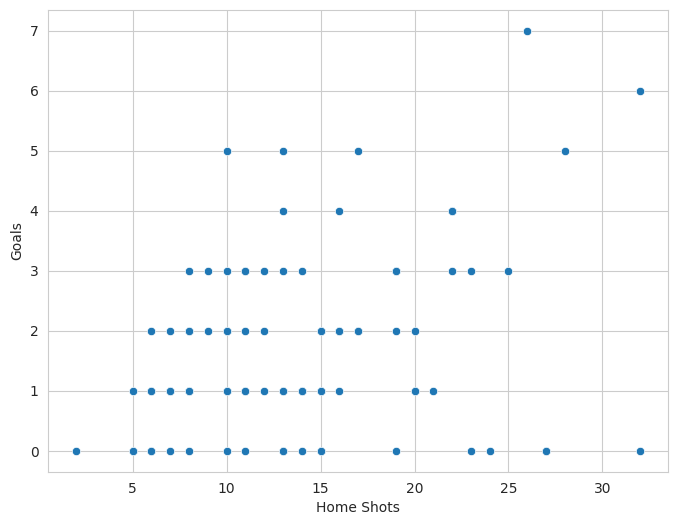

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["home_total_shots"],
    y=df["home_score"]
)

plt.xlabel("Home Shots")
plt.ylabel("Goals")
plt.show()

# Shots on target

In [29]:
df["home_sot"].describe()

count    92.000000
mean      4.760870
std       3.075495
min       0.000000
25%       2.750000
50%       4.000000
75%       6.250000
max      15.000000
Name: home_sot, dtype: float64

In [30]:
df["away_sot"].describe()

count    92.000000
mean      3.586957
std       2.395748
min       0.000000
25%       2.000000
50%       3.000000
75%       5.000000
max      10.000000
Name: away_sot, dtype: float64

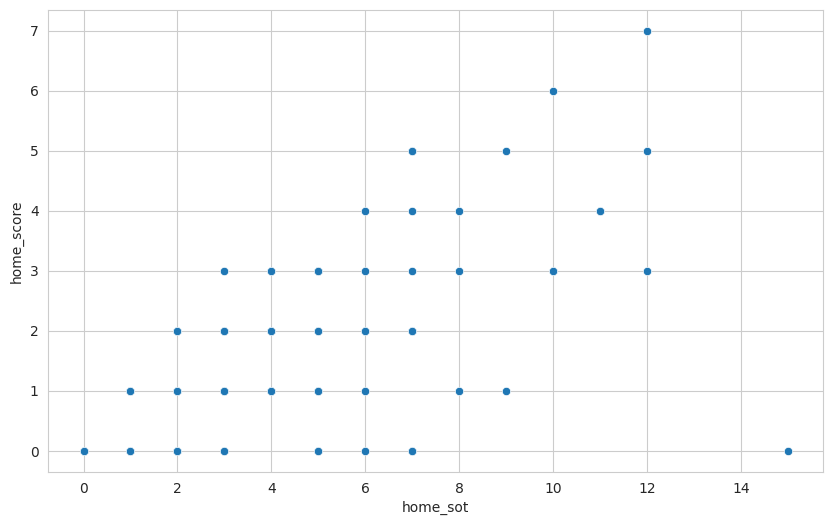

In [31]:
sns.scatterplot(
    x=df["home_sot"],
    y=df["home_score"]
)

plt.show()

# corners 

In [32]:
corners = pd.DataFrame({
    "Home":df["home_corners"],
    "Away":df["away_corners"]
})

corners.describe()

,Home,Away
count,92.000000,92.000000
mean,5.206522,3.967391
std,3.525536,2.723327
min,0.000000,0.000000
25%,3.000000,2.000000
50%,4.000000,3.000000
75%,7.000000,5.000000
max,19.000000,14.000000


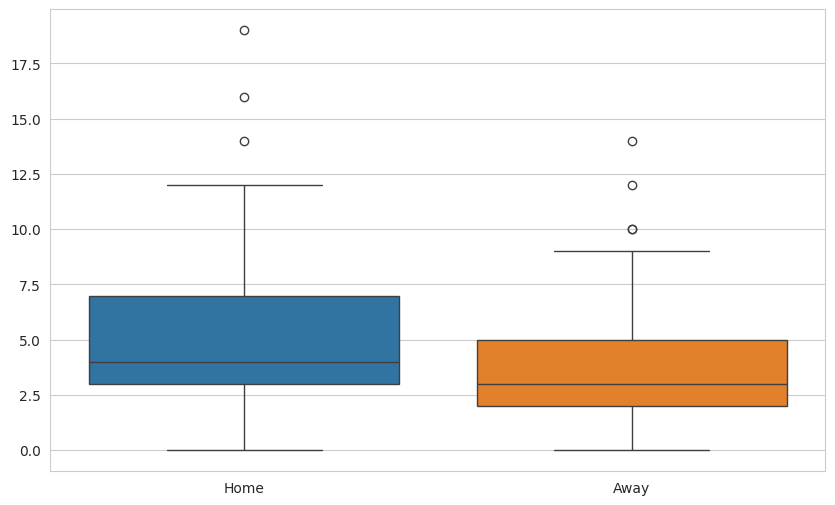

In [33]:
sns.boxplot(data=corners)

plt.show()

# Fouls

In [34]:
fouls = pd.DataFrame({
    "Home":df["home_fouls"],
    "Away":df["away_fouls"]
})

fouls.describe()

,Home,Away
count,92.000000,92.000000
mean,11.413043,11.217391
std,3.981143,4.174296
min,3.000000,1.000000
25%,9.000000,8.000000
50%,11.000000,11.000000
75%,13.000000,14.000000
max,24.000000,24.000000


# cards 

In [35]:
yellow = df["home_cards_yellow"].sum()+df["away_cards_yellow"].sum()

red = df["home_cards_red"].sum()+df["away_cards_red"].sum()

print("Yellow:",yellow)
print("Red:",red)

Yellow: 237
Red: 13


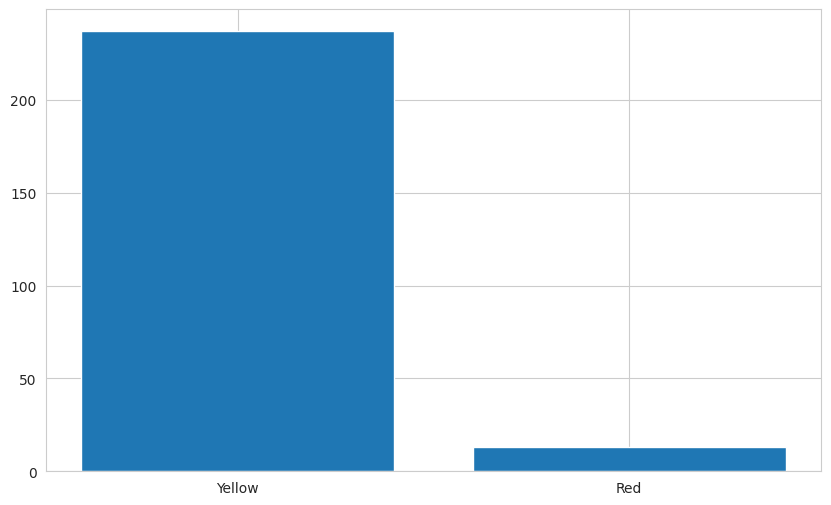

In [36]:
plt.bar(
    ["Yellow","Red"],
    [yellow,red]
)

plt.show()

# Venue

In [37]:
stadiums = df.groupby("venue").agg({
    "attendance":"sum"
}).sort_values(
    "attendance",
    ascending=False
)

stadiums.head(10)

,attendance
venue,
"Estadio Banorte, Coyoacán","80,82480,82480,82480,82480,824"
"MetLife Stadium, East Rutherford","80,66380,54580,66380,66380,66380,66380,663"
"SoFi Stadium, Inglewood","70,49270,10870,02670,31770,49269,23770,492"
"AT&T Stadium, Arlington","69,28570,38970,64970,13770,64969,66570,244"
"GEHA Field at Arrowhead Stadium, Kansas City","69,04568,59868,39169,04569,045"
"Lincoln Financial Field, Philadelphia","68,27468,32468,32468,32468,32468,324"
"Reliant Stadium, Houston","68,02168,77768,77768,77768,27868,77768,777"
"Levi's Stadium, Santa Clara","67,96668,52768,82768,37168,82768,827"
"Mercedes-Benz Stadium, Atlanta","67,64067,44268,23968,23968,23968,239"


# Referees

In [38]:
refs = df["referee"].value_counts()

refs.head(10)

referee
Wilton Sampaio      3
Said Martínez       3
Danny Makkelie      3
Ismail Elfath       3
Jesús Valenzuela    3
Slavko Vinčič       3
Clément Turpin      3
Maurizio Mariani    3
Alireza Faghani     3
Adham Makhadmeh     3
Name: count, dtype: int64

# Formations

In [39]:
formations = pd.concat([
    df["home_formation"],
    df["away_formation"]
])

formations.value_counts()

4-2-3-1    53
4-1-4-1    46
4-2-2-2    35
5-4-1      18
3-4-3      17
5-3-2       7
4-3-2-1     2
3-1-4-2     2
3-5-2       1
3-4-1-2     1
4-3-1-2     1
4-1-3-2     1
Name: count, dtype: int64

# Creating teams table

In [40]:
teams = pd.concat([
    df["home_team"],
    df["away_team"]
])

teams.value_counts()

Mexico            5
Canada            5
Brazil            5
Paraguay          5
Norway            5
Morocco           5
England           5
France            5
Belgium           4
Spain             4
Sweden            4
United States     4
Australia         4
Côte d'Ivoire     4
Netherlands       4
Germany           4
Egypt             4
Croatia           4
Congo DR          4
Cabo Verde        4
Algeria           4
Ghana             4
Austria           4
Argentina         4
Colombia          4
Japan             4
Senegal           4
South Africa      4
Bosnia–Herz       4
Portugal          4
Ecuador           4
Switzerland       4
Saudi Arabia      3
IR Iran           3
Qatar             3
Haiti             3
Korea Republic    3
Scotland          3
Iraq              3
Uzbekistan        3
New Zealand       3
Uruguay           3
Tunisia           3
Türkiye           3
Czechia           3
Curaçao           3
Jordan            3
Panama            3
Name: count, dtype: int64

In [41]:
home = df[[
    "home_team",
    "home_score",
    "away_score",
    "home_possession",
    "home_total_shots",
    "home_sot",
    "home_corners",
    "home_fouls"
]].copy()

home.columns = [
    "team",
    "goals_for",
    "goals_against",
    "possession",
    "shots",
    "shots_on_target",
    "corners",
    "fouls"
]

In [42]:
away = df[[
    "away_team",
    "away_score",
    "home_score",
    "away_possession",
    "away_total_shots",
    "away_sot",
    "away_corners",
    "away_fouls"
]].copy()

away.columns = home.columns

In [43]:
team_stats = pd.concat([home, away])

team_stats.head()


,team,goals_for,goals_against,possession,shots,shots_on_target,corners,fouls
0,Mexico,2,0,61,16,4,3,12
1,Korea Republic,2,1,62,15,6,4,9
2,Canada,1,1,61,13,4,9,10
3,United States,4,1,65,16,6,3,13
4,Qatar,1,1,32,7,4,3,12


# team summary 

In [44]:
team_summary = team_stats.groupby("team").agg({
    "goals_for":"sum",
    "goals_against":"sum",
    "shots":"mean",
    "shots_on_target":"mean",
    "possession":"mean",
    "corners":"mean",
    "fouls":"mean"
})

team_summary.sort_values(
    "goals_for",
    ascending=False
)

,goals_for,goals_against,shots,shots_on_target,possession,corners,fouls
team,,,,,,,
France,14,2,17.600000,7.800000,60.800000,7.200000,9.800000
Norway,12,9,10.600000,5.000000,53.000000,4.400000,9.600000
Argentina,11,3,14.000000,6.250000,59.750000,4.250000,11.500000
Germany,11,5,18.500000,7.000000,65.000000,8.500000,12.750000
England,11,5,16.000000,6.400000,58.200000,6.200000,10.800000
Netherlands,11,5,11.500000,5.500000,53.250000,4.500000,11.000000
Mexico,10,3,14.000000,4.200000,52.200000,3.800000,11.600000
Brazil,10,4,14.800000,6.000000,53.000000,5.400000,10.200000
Senegal,10,9,17.250000,5.750000,55.250000,5.500000,9.000000


In [45]:
team_summary = team_stats.groupby("team").agg({
    "goals_for":"sum",
    "goals_against":"sum",
    "shots":"mean",
    "shots_on_target":"mean",
    "possession":"mean",
    "corners":"mean",
    "fouls":"mean"
})

team_summary = team_summary.sort_values(
    "goals_for",
    ascending=False
)

team_summary.head(10)

,goals_for,goals_against,shots,shots_on_target,possession,corners,fouls
team,,,,,,,
France,14,2,17.60,7.80,60.80,7.20,9.80
Norway,12,9,10.60,5.00,53.00,4.40,9.60
Argentina,11,3,14.00,6.25,59.75,4.25,11.50
Germany,11,5,18.50,7.00,65.00,8.50,12.75
England,11,5,16.00,6.40,58.20,6.20,10.80
Netherlands,11,5,11.50,5.50,53.25,4.50,11.00
Mexico,10,3,14.00,4.20,52.20,3.80,11.60
Brazil,10,4,14.80,6.00,53.00,5.40,10.20
Senegal,10,9,17.25,5.75,55.25,5.50,9.00


# plot most 10 teams scored goals 

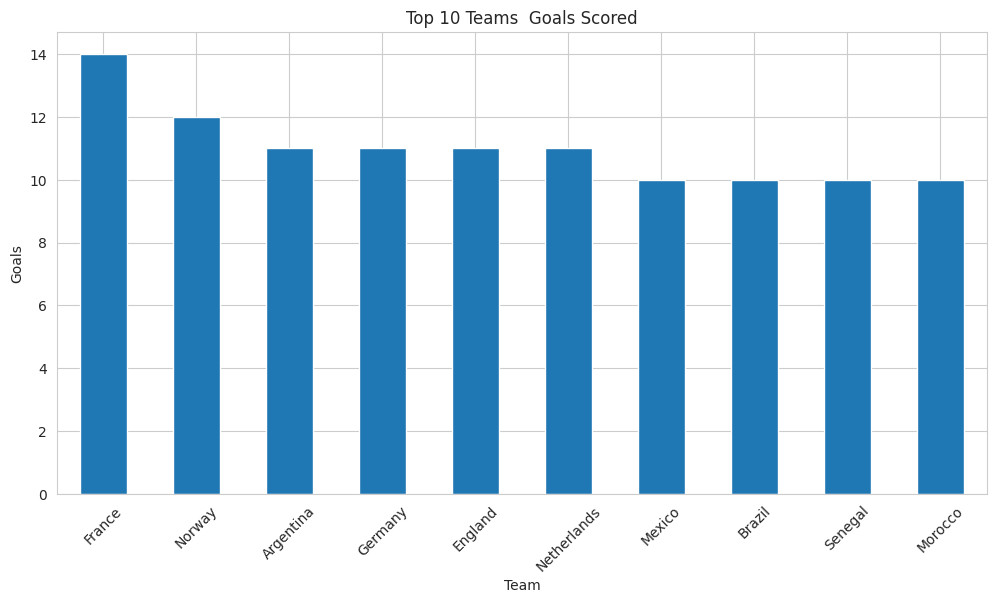

In [46]:
plt.figure(figsize=(12,6))

team_summary["goals_for"].head(10).plot(
    kind="bar"
)

plt.title("Top 10 Teams  Goals Scored")
plt.xlabel("Team")
plt.ylabel("Goals")

plt.xticks(rotation=45)
plt.show()

# plot goals for vs goals against teams 

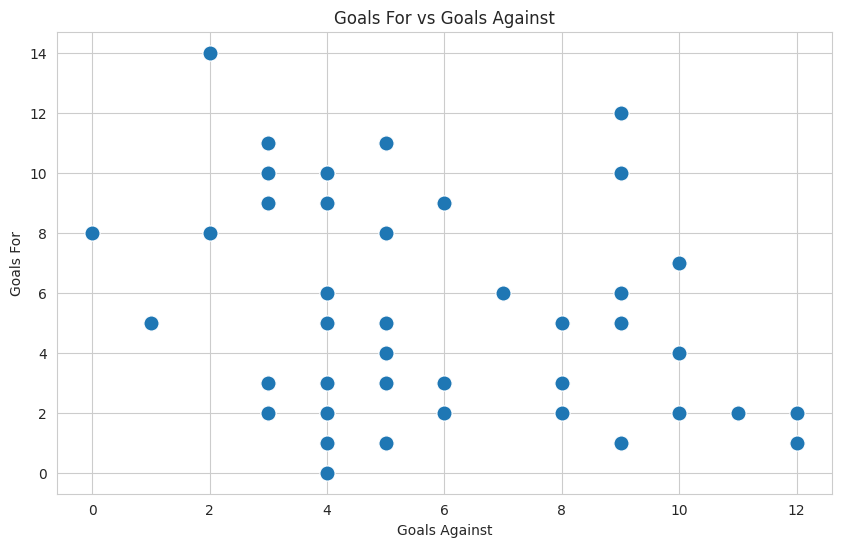

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=team_summary,
    x="goals_against",
    y="goals_for",
    s=120
)

plt.title("Goals For vs Goals Against")
plt.xlabel("Goals Against")
plt.ylabel("Goals For")

plt.show()

# Average Possession for each team

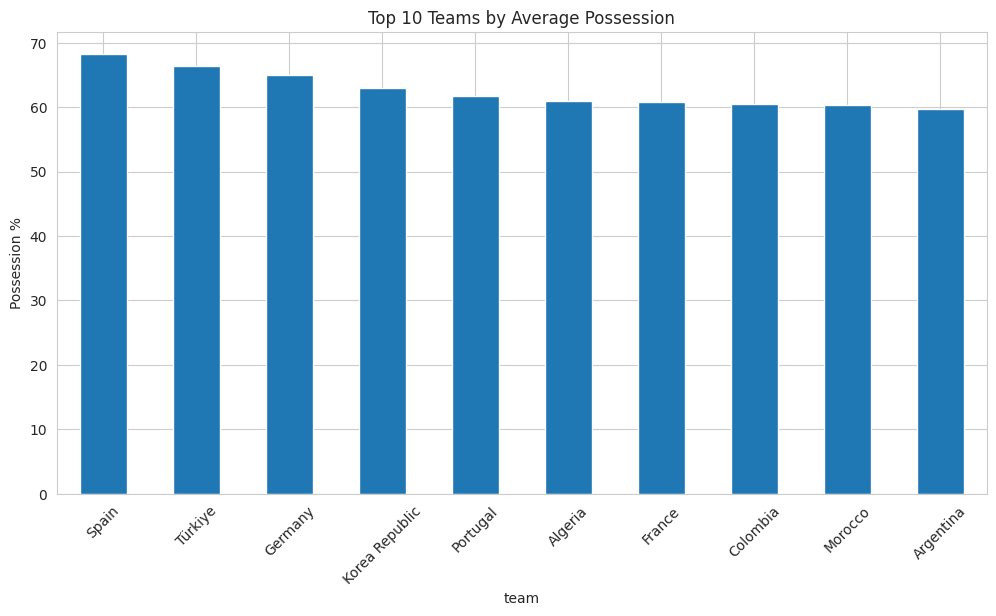

In [48]:
plt.figure(figsize=(12,6))

team_summary.sort_values(
    "possession",
    ascending=False
)["possession"].head(10).plot(
    kind="bar"
)

plt.title("Top 10 Teams by Average Possession")
plt.ylabel("Possession %")

plt.xticks(rotation=45)
plt.show()

# Shots vs Shots on Target

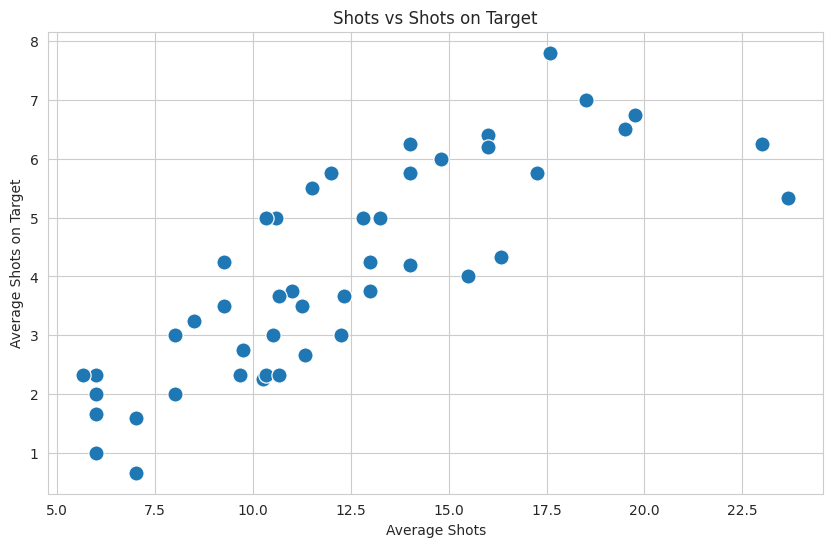

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=team_summary,
    x="shots",
    y="shots_on_target",
    s=120
)

plt.title("Shots vs Shots on Target")
plt.xlabel("Average Shots")
plt.ylabel("Average Shots on Target")

plt.show()

# Team Performance Comparison

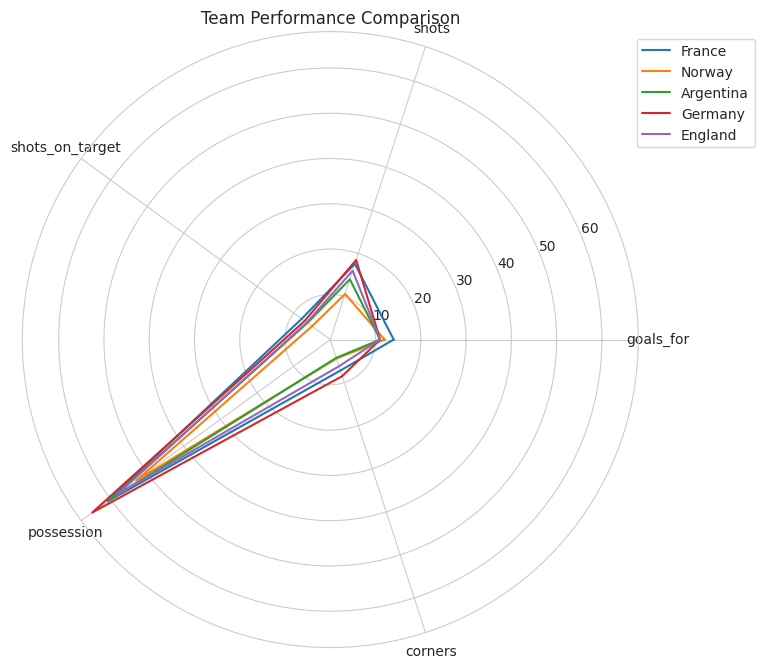

In [50]:
from math import pi

team = team_summary.head(5)

categories = [
    "goals_for",
    "shots",
    "shots_on_target",
    "possession",
    "corners"
]

angles = [
    n / float(len(categories)) * 2*pi
    for n in range(len(categories))
]

angles += angles[:1]

plt.figure(figsize=(8,8))

for idx,row in team.iterrows():
    values = row[categories].tolist()
    values += values[:1]

    plt.polar(
        angles,
        values,
        label=idx
    )

plt.xticks(
    angles[:-1],
    categories
)

plt.legend(
    bbox_to_anchor=(1.2,1)
)

plt.title("Team Performance Comparison")
plt.show()

# Heatmap

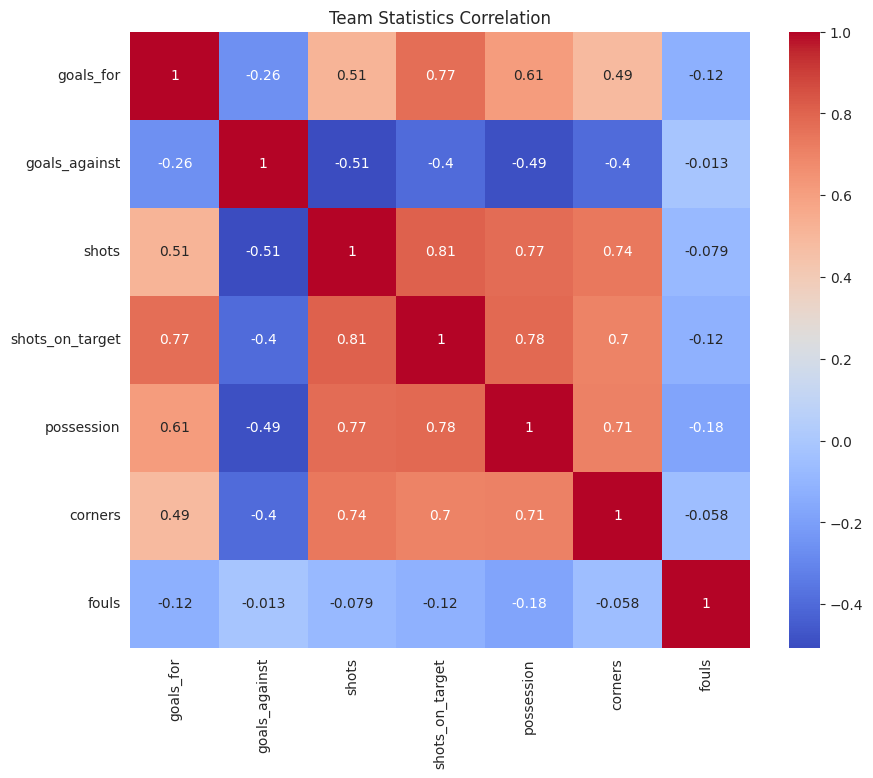

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    team_summary.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Team Statistics Correlation")
plt.show()

In [52]:
team_summary.to_csv("team_summary.csv", index=True)
team_stats.to_csv("team_stats.csv", index=False)
df.to_csv("matches_clean.csv", index=False)